# Notebook 01 — Análise Exploratória dos Dados (EDA)

## Tech Challenge Fase 1 — Classificação de SRAG (SIVEP-Gripe)

**Objetivo:** Carregar o dataset SIVEP-Gripe e explorar suas características antes de qualquer transformação.

**Dataset:** INFLUD24 — Síndrome Respiratória Aguda Grave Hospitalizada (2024)  
**Fonte:** OpenDataSUS / Ministério da Saúde  
**Variável alvo:** `EVOLUCAO` → 1=Cura | 2=Óbito (binarizado em notebooks seguintes)

---

## Estrutura do notebook
1. Configuração do ambiente
2. Carregamento dos dados
3. Inspeção inicial
4. Distribuição do target
5. Análise de valores ausentes
6. Distribuições de variáveis-chave
7. Visualizações de sintomas e comorbidades
8. Análise temporal

## 1. Configuração do Ambiente

In [2]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Adiciona o diretório raiz ao path para importar os módulos src/
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from src.tabular.load_data import (
    carregar_dataset,
    inspecionar_dataset,
    resumo_target
)

# Configurações de visualização
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Ambiente configurado com sucesso.')

Ambiente configurado com sucesso.


## 2. Carregamento dos Dados

> **Atenção:** O arquivo CSV deve estar em `../data/raw/INFLUD24-26-06-2025.csv`.  
> Caso queira testar com menos dados, use o parâmetro `nrows=10000`.

In [3]:
# Carrega o dataset completo (~268 mil registros)
# Para teste rápido: carregar_dataset(nrows=10000)
df = carregar_dataset()

print(f'\nShape: {df.shape}')
df.head(3)

Dataset carregado: 267,984 registros, 194 colunas

Shape: (267984, 194)


,NU_NOTIFIC,DT_NOTIFIC,SEM_NOT,DT_SIN_PRI,SEM_PRI,SG_UF_NOT,ID_REGIONA,CO_REGIONA,ID_MUNICIP,CO_MUN_NOT,CS_SEXO,DT_NASC,NU_IDADE_N,TP_IDADE,COD_IDADE,CS_GESTANT,CS_RACA,CS_ETINIA,CS_ESCOL_N,ID_PAIS,CO_PAIS,SG_UF,ID_RG_RESI,CO_RG_RESI,ID_MN_RESI,...,FAB_ADIC,FAB_RE_BI,LOTE_1_COV,LOTE_2_COV,LOTE_REF,LOTE_REF2,LOTE_ADIC,LOT_RE_BI,FNT_IN_COV,TRAT_COV,TIPO_TRAT,DT_TRT_COV,OUT_TRAT,SURTO_SG,CO_DETEC,VG_OMS,VG_OMSOUT,VG_LIN,VG_MET,VG_METOUT,VG_DTRES,VG_ENC,VG_REINF,VG_CODEST,REINF
0,31699870911712,2024-01-24,4,2024-01-22,4,GO,CENTRAL,1779.00,GOIANIA,520870.00,M,2023-08-20,3,2,2003,6,5,CABIXI,NaN,BRASIL,1,GO,PIRINEUS,1792.00,ABADIANIA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2.00,NaN,NaN,NaN,2.00,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
1,31701367675066,2024-04-25,17,2024-04-19,16,DF,NaN,NaN,BRASILIA,530010.00,M,1959-05-06,64,3,3064,6,4,NaN,9.00,BRASIL,1,DF,NaN,NaN,TAGUATINGA,...,NaN,NaN,FA9095,FF8848,NaN,NaN,NaN,NaN,2,2.00,NaN,NaN,NaN,2.00,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,31701948644835,2024-01-09,2,2024-01-08,2,SP,GVE I CAPITAL,1331.00,SAO PAULO,355030.00,M,2023-03-14,9,2,2009,6,1,NaN,0.00,BRASIL,1,SP,GVE I CAPITAL,1331.00,SAO PAULO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2.00,NaN,NaN,NaN,2.00,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2


## 3. Inspeção Inicial

In [4]:
# Resumo completo: tipos, nulos, amostra
inspecionar_dataset(df)

Shape: (267984, 194)

Tipos de dados:
float64    104
object      77
int64       13
Name: count, dtype: int64

Valores nulos por coluna (top 20):


             Nulos  % Nulos
DT_RT_VGM   267984   100.00
DT_VGM      267984   100.00
PAIS_VGM    267984   100.00
CO_PS_VGM   267984   100.00
LO_PS_VGM   267984   100.00
TABAG       267984   100.00
VG_REINF    267984   100.00
AN_PARA2    267976   100.00
FLUBLI_OUT  267969    99.99
VG_METOUT   267965    99.99
AN_PARA1    267953    99.99
AN_PARA3    267926    99.98
PCR_PARA4   267860    99.95
AN_ADENO    267835    99.94
PCR_PARA2   267829    99.94
PCR_PARA1   267749    99.91
VG_OMSOUT   267728    99.90
FLUASU_OUT  267667    99.88
OUT_ANTIV   267474    99.81
OUT_SOR     267458    99.80

Amostra (primeiras 3 linhas):
       NU_NOTIFIC  DT_NOTIFIC  SEM_NOT  DT_SIN_PRI  SEM_PRI SG_UF_NOT     ID_REGIONA  CO_REGIONA ID_MUNICIP  CO_MUN_NOT CS_SEXO     DT_NASC  NU_IDADE_N  TP_IDADE COD_IDADE  CS_GESTANT  CS_RACA CS_ETINIA  CS_ESCOL_N ID_PAIS  CO_PAIS SG_UF     ID_RG_RESI  CO_RG_RESI  ID_MN_RESI  CO_MUN_RES  CS_ZONA  NOSOCOMIAL  AVE_SUINO  FEBRE  TOSSE  GARGANTA  DISPNEIA  DESC_RESP  SATURACAO  DIA

In [5]:
# Estatísticas descritivas das variáveis numéricas
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
NU_NOTIFIC,267984.000000,31720825640390.472656,8494210425.433093,31699870911712.000000,31714127989648.750000,31720004083200.500000,31727350310844.750000,31750857693204.000000
SEM_NOT,267984.000000,26.137915,13.595568,1.000000,15.000000,25.000000,37.000000,52.000000
SEM_PRI,267984.000000,25.836378,13.633706,1.000000,15.000000,24.000000,37.000000,52.000000
CO_REGIONA,235197.000000,1581.276411,691.462167,1331.000000,1352.000000,1449.000000,1533.000000,6256.000000
CO_MUN_NOT,267978.000000,346463.175324,92694.350770,110002.000000,310620.000000,352210.000000,411370.000000,530010.000000
NU_IDADE_N,267984.000000,30.818183,32.650118,-4.000000,3.000000,10.000000,65.000000,114.000000
TP_IDADE,267984.000000,2.735995,0.471939,1.000000,3.000000,3.000000,3.000000,3.000000
CS_GESTANT,267984.000000,5.832412,0.667547,0.000000,6.000000,6.000000,6.000000,9.000000
CS_RACA,267984.000000,3.210356,2.466788,1.000000,1.000000,4.000000,4.000000,9.000000
CS_ESCOL_N,166785.000000,5.033144,3.387883,0.000000,2.000000,5.000000,9.000000,9.000000


## 4. Distribuição do Target (EVOLUCAO)

A variável `EVOLUCAO` registra o desfecho clínico do paciente:
- **1** = Cura  
- **2** = Óbito  
- **3** = Óbito por outras causas  
- **9** = Ignorado  

Para o modelo, usaremos apenas registros com desfecho definitivo (1 ou 2), criando um problema de classificação binária.


Distribuição de 'EVOLUCAO':
                           Contagem  % Total
EVOLUCAO                                    
1.0 — Cura                   219708    81.99
2.0 — Óbito                   20728     7.73
nan — NaN/Outro               14906     5.56
3.0 — Óbito outras causas      8057     3.01
9.0 — Ignorado                 4585     1.71


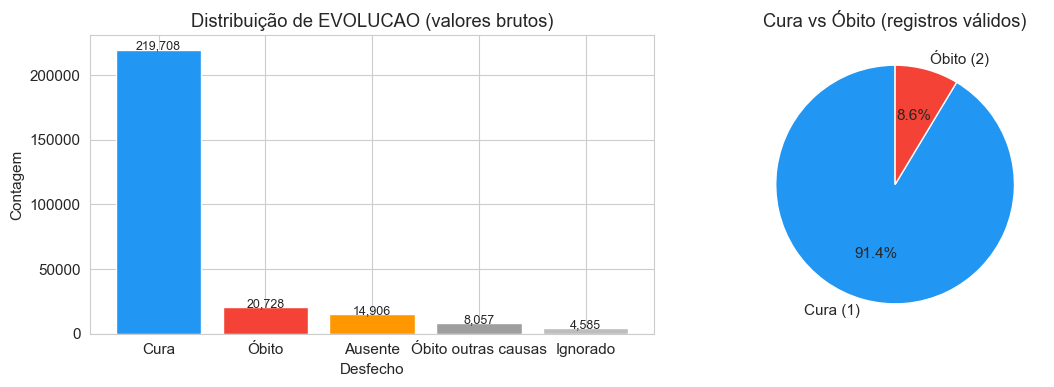

Registros válidos (Cura + Óbito): 240,436
Arquivo salvo em: /Users/arthuraugustopaulahardman/projetos/pos_fiap/fase1/tech-challenge-srag-v2/results/figures/distribuicao_target.png


In [6]:
from pathlib import Path
import matplotlib.pyplot as plt

# =========================
# Resumo do target
# =========================
resumo = resumo_target(df)

# =========================
# Criar figura
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# =========================
# Gráfico 1 — Contagem geral
# =========================
evolucao_counts = df['EVOLUCAO'].value_counts(dropna=False)

mapa = {
    1: 'Cura',
    2: 'Óbito',
    3: 'Óbito outras causas',
    9: 'Ignorado'
}

# Ajuste de labels (tratando NaN)
evolucao_counts.index = evolucao_counts.index.map(
    lambda x: mapa.get(x, 'Ausente' if pd.isna(x) else str(x))
)

axes[0].bar(
    evolucao_counts.index,
    evolucao_counts.values,
    color=['#2196F3', '#F44336', '#FF9800', '#9E9E9E', '#BDBDBD']
)

axes[0].set_title('Distribuição de EVOLUCAO (valores brutos)')
axes[0].set_xlabel('Desfecho')
axes[0].set_ylabel('Contagem')

# Adicionar valores acima das barras
for i, v in enumerate(evolucao_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# =========================
# Gráfico 2 — Cura vs Óbito
# =========================
df_valido = df[df['EVOLUCAO'].isin([1, 2])]

cores = ['#2196F3', '#F44336']
labels = ['Cura (1)', 'Óbito (2)']

contagens = df_valido['EVOLUCAO'].value_counts()

axes[1].pie(
    contagens.values,
    labels=labels,
    colors=cores,
    autopct='%1.1f%%',
    startangle=90
)

axes[1].set_title('Cura vs Óbito (registros válidos)')

# =========================
# Salvar imagem (CORRIGIDO)
# =========================

# Caminho absoluto seguro baseado na raiz do projeto
PROJECT_ROOT = Path.cwd().parent
output_dir = PROJECT_ROOT / "results" / "figures"

# Cria a pasta automaticamente se não existir
output_dir.mkdir(parents=True, exist_ok=True)

# Salva o gráfico
plt.tight_layout()
plt.savefig(output_dir / "distribuicao_target.png", dpi=150, bbox_inches='tight')

plt.show()

# =========================
# Print final
# =========================
print(f"Registros válidos (Cura + Óbito): {len(df_valido):,}")
print(f"Arquivo salvo em: {output_dir / 'distribuicao_target.png'}")

## 5. Análise de Valores Ausentes

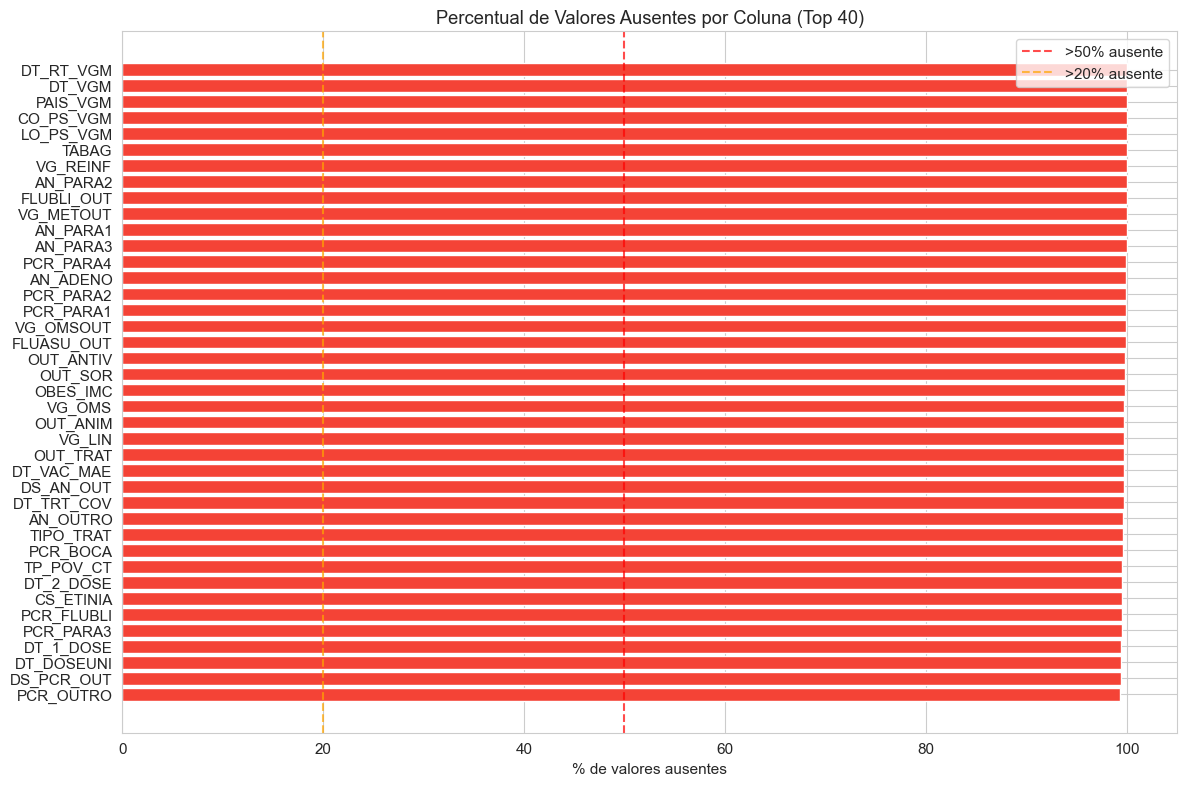

Colunas sem nenhum valor ausente: 19
Colunas com > 50% ausentes: 117
Colunas com > 20% ausentes: 133


In [7]:
# Calcular percentual de nulos por coluna
pct_nulos = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
pct_nulos_relevantes = pct_nulos[pct_nulos > 0].head(40)

fig, ax = plt.subplots(figsize=(12, 8))
cores = ['#F44336' if v > 50 else '#FF9800' if v > 20 else '#4CAF50' for v in pct_nulos_relevantes.values]
ax.barh(pct_nulos_relevantes.index[::-1], pct_nulos_relevantes.values[::-1], color=cores[::-1])
ax.set_xlabel('% de valores ausentes')
ax.set_title('Percentual de Valores Ausentes por Coluna (Top 40)')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='>50% ausente')
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='>20% ausente')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/valores_ausentes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Colunas sem nenhum valor ausente: {(pct_nulos == 0).sum()}')
print(f'Colunas com > 50% ausentes: {(pct_nulos > 50).sum()}')
print(f'Colunas com > 20% ausentes: {(pct_nulos > 20).sum()}')

## 6. Distribuições de Variáveis-Chave

In [8]:
# Trabalharemos apenas com registros válidos (Cura ou Óbito) daqui em diante
df_valido = df[df['EVOLUCAO'].isin([1, 2])].copy()
df_valido['OBITO'] = (df_valido['EVOLUCAO'] == 2).astype(int)
print(f'Dataset filtrado: {len(df_valido):,} registros')

Dataset filtrado: 240,436 registros


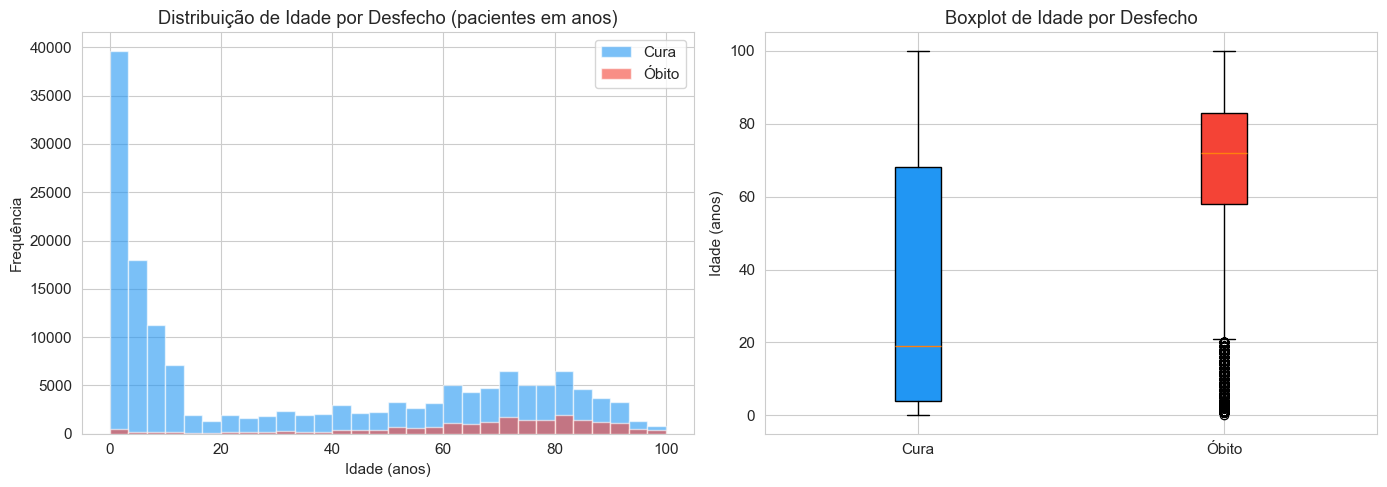

In [9]:
# Distribuição de Idade por desfecho
# A coluna NU_IDADE_N pode ser em dias, meses ou anos dependendo de TP_IDADE
# Vamos focar em pacientes com TP_IDADE == 3 (anos)
df_anos = df_valido[df_valido['TP_IDADE'] == 3].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de idade por desfecho
for obito, label, cor in [(0, 'Cura', '#2196F3'), (1, 'Óbito', '#F44336')]:
    subset = df_anos[df_anos['OBITO'] == obito]['NU_IDADE_N']
    axes[0].hist(subset.clip(0, 100), bins=30, alpha=0.6, label=label, color=cor)

axes[0].set_title('Distribuição de Idade por Desfecho (pacientes em anos)')
axes[0].set_xlabel('Idade (anos)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Boxplot
dados_box = [
    df_anos[df_anos['OBITO'] == 0]['NU_IDADE_N'].clip(0, 100),
    df_anos[df_anos['OBITO'] == 1]['NU_IDADE_N'].clip(0, 100),
]
bp = axes[1].boxplot(dados_box, labels=['Cura', 'Óbito'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][1].set_facecolor('#F44336')
axes[1].set_title('Boxplot de Idade por Desfecho')
axes[1].set_ylabel('Idade (anos)')

plt.tight_layout()
plt.savefig('../results/figures/distribuicao_idade.png', dpi=150, bbox_inches='tight')
plt.show()

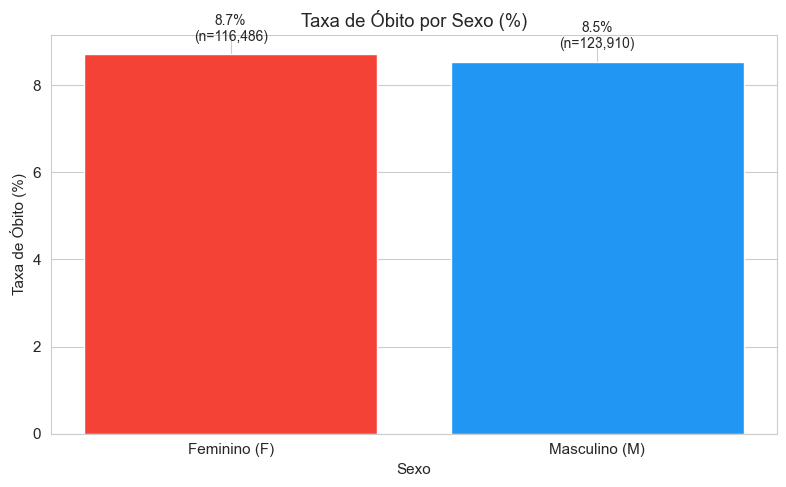

In [10]:
# Distribuição por Sexo
fig, ax = plt.subplots(figsize=(8, 5))

sexo_obito = df_valido.groupby('CS_SEXO')['OBITO'].agg(['sum', 'count'])
sexo_obito['taxa_obito'] = sexo_obito['sum'] / sexo_obito['count'] * 100
sexo_obito = sexo_obito[sexo_obito.index.isin(['M', 'F'])]

bars = ax.bar(sexo_obito.index, sexo_obito['taxa_obito'], color=['#F44336', '#2196F3'], edgecolor='white')
ax.set_title('Taxa de Óbito por Sexo (%)')
ax.set_xlabel('Sexo')
ax.set_ylabel('Taxa de Óbito (%)')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Feminino (F)', 'Masculino (M)'])

for bar, (idx, row) in zip(bars, sexo_obito.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{row['taxa_obito']:.1f}%\n(n={int(row['count']):,})",
            ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../results/figures/taxa_obito_por_sexo.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Sintomas e Comorbidades

Nos campos de sintomas e comorbidades, os valores são:
- **1** = Sim  
- **2** = Não  
- **9** = Ignorado

In [11]:
SINTOMAS = ['FEBRE', 'TOSSE', 'GARGANTA', 'DISPNEIA', 'DESC_RESP',
            'SATURACAO', 'DIARREIA', 'VOMITO', 'DOR_ABD', 'FADIGA',
            'PERD_OLFT', 'PERD_PALA']

COMORBIDADES = ['CARDIOPATI', 'DIABETES', 'OBESIDADE', 'ASMA', 'PNEUMOPATI',
                'IMUNODEPRE', 'RENAL', 'NEUROLOGIC', 'HEPATICA', 'HEMATOLOGI']

def calcular_prevalencia(df, colunas, grupo_col='OBITO'):
    """Calcula prevalência (%) de cada coluna por grupo (Cura=0 / Óbito=1)."""
    resultados = []
    for col in colunas:
        if col not in df.columns:
            continue
        # Presença = valor 1 (Sim)
        presente = (df[col] == 1).astype(int)
        for grupo in [0, 1]:
            mask = df[grupo_col] == grupo
            prev = presente[mask].mean() * 100
            resultados.append({'variavel': col, 'grupo': grupo, 'prevalencia': prev})
    return pd.DataFrame(resultados)

print('Calculando prevalências...')

Calculando prevalências...


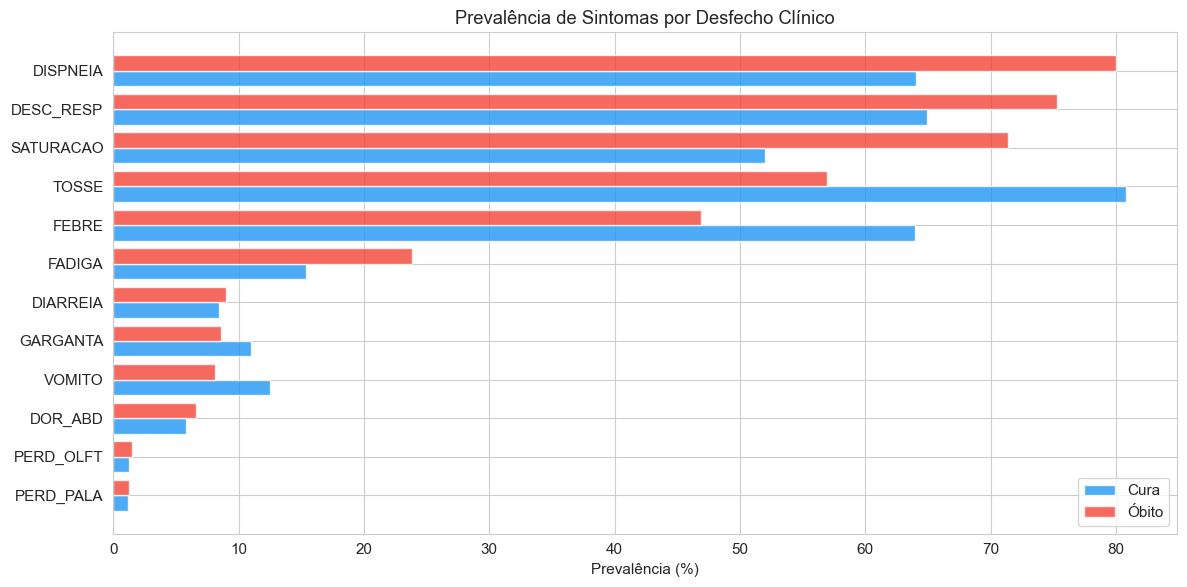

In [12]:
# Prevalência de sintomas por desfecho
df_sint = calcular_prevalencia(df_valido, SINTOMAS)

fig, ax = plt.subplots(figsize=(12, 6))
df_pivot = df_sint.pivot(index='variavel', columns='grupo', values='prevalencia')
df_pivot.columns = ['Cura', 'Óbito']
df_pivot = df_pivot.sort_values('Óbito', ascending=True)

x = range(len(df_pivot))
ax.barh([i - 0.2 for i in x], df_pivot['Cura'], height=0.4, label='Cura', color='#2196F3', alpha=0.8)
ax.barh([i + 0.2 for i in x], df_pivot['Óbito'], height=0.4, label='Óbito', color='#F44336', alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(df_pivot.index)
ax.set_xlabel('Prevalência (%)')
ax.set_title('Prevalência de Sintomas por Desfecho Clínico')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/prevalencia_sintomas.png', dpi=150, bbox_inches='tight')
plt.show()

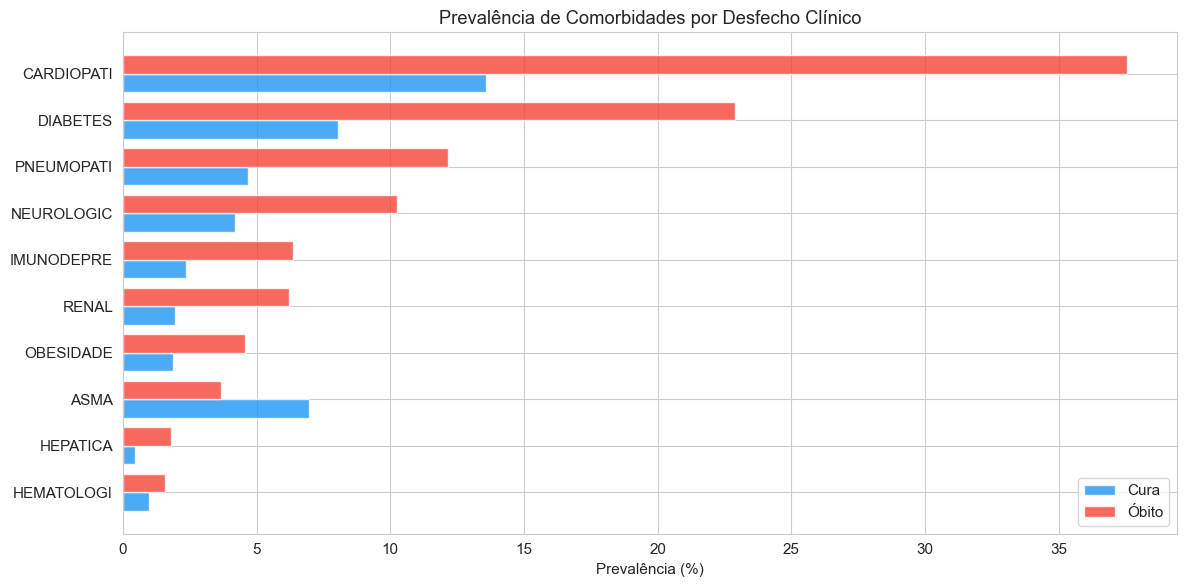

In [13]:
# Prevalência de comorbidades por desfecho
df_comorb = calcular_prevalencia(df_valido, COMORBIDADES)

fig, ax = plt.subplots(figsize=(12, 6))
df_pivot2 = df_comorb.pivot(index='variavel', columns='grupo', values='prevalencia')
df_pivot2.columns = ['Cura', 'Óbito']
df_pivot2 = df_pivot2.sort_values('Óbito', ascending=True)

x = range(len(df_pivot2))
ax.barh([i - 0.2 for i in x], df_pivot2['Cura'], height=0.4, label='Cura', color='#2196F3', alpha=0.8)
ax.barh([i + 0.2 for i in x], df_pivot2['Óbito'], height=0.4, label='Óbito', color='#F44336', alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(df_pivot2.index)
ax.set_xlabel('Prevalência (%)')
ax.set_title('Prevalência de Comorbidades por Desfecho Clínico')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/prevalencia_comorbidades.png', dpi=150, bbox_inches='tight')
plt.show()

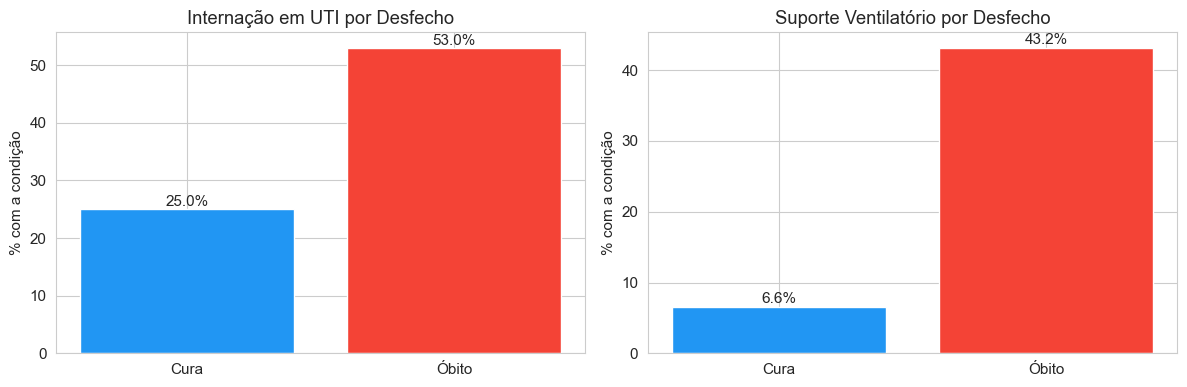

In [14]:
# UTI e Suporte Ventilatório
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, titulo in [
    (axes[0], 'UTI', 'Internação em UTI por Desfecho'),
    (axes[1], 'SUPORT_VEN', 'Suporte Ventilatório por Desfecho'),
]:
    if col in df_valido.columns:
        tab = df_valido.groupby('OBITO')[col].apply(lambda x: (x == 1).mean() * 100)
        ax.bar(['Cura', 'Óbito'], tab.values, color=['#2196F3', '#F44336'])
        ax.set_title(titulo)
        ax.set_ylabel('% com a condição')
        for i, v in enumerate(tab.values):
            ax.text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.savefig('../results/figures/uti_suporte_ventilatorio.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Análise Temporal

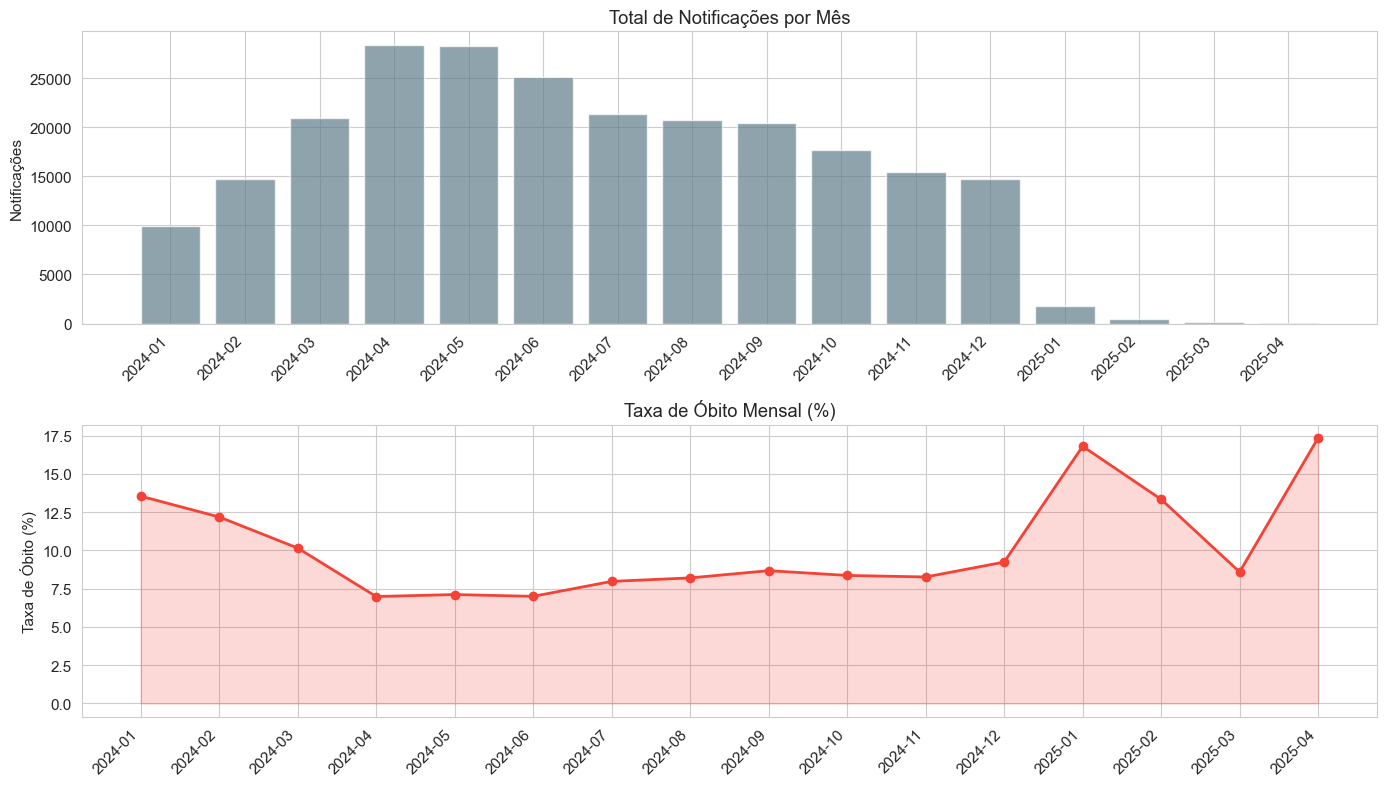

In [15]:
# Evolução mensal de casos e óbitos
df_valido['DT_NOTIFIC'] = pd.to_datetime(df_valido['DT_NOTIFIC'], errors='coerce')
df_valido['MES_NOTIFIC'] = df_valido['DT_NOTIFIC'].dt.to_period('M')

mensal = df_valido.groupby('MES_NOTIFIC').agg(
    total=('OBITO', 'count'),
    obitos=('OBITO', 'sum')
).reset_index()
mensal['taxa_obito'] = mensal['obitos'] / mensal['total'] * 100
mensal = mensal[mensal['total'] > 50]  # Remove meses com poucos registros

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

x = range(len(mensal))
axes[0].bar(x, mensal['total'], color='#607D8B', alpha=0.7)
axes[0].set_title('Total de Notificações por Mês')
axes[0].set_ylabel('Notificações')
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(m) for m in mensal['MES_NOTIFIC']], rotation=45, ha='right')

axes[1].plot(x, mensal['taxa_obito'], marker='o', color='#F44336', linewidth=2)
axes[1].fill_between(x, mensal['taxa_obito'], alpha=0.2, color='#F44336')
axes[1].set_title('Taxa de Óbito Mensal (%)')
axes[1].set_ylabel('Taxa de Óbito (%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(m) for m in mensal['MES_NOTIFIC']], rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../results/figures/evolucao_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Conclusões da EDA

**Principais observações:**

- O dataset possui **194 colunas** e ~268 mil registros — grande volume e alta dimensionalidade
- Muitas colunas apresentam **alto percentual de ausência**, especialmente variáveis laboratoriais
- O target `EVOLUCAO` mostra **desbalanceamento** entre Cura e Óbito — será necessário tratar nas etapas de modelagem
- **Idade** é um fator de risco evidente: pacientes que foram a óbito tendem a ser mais velhos
- **Comorbidades** como cardiopatia, diabetes e obesidade aparecem com maior frequência entre óbitos
- **UTI** e **suporte ventilatório** são fortemente associados ao desfecho
- Sintomas como **dispneia** e **saturação baixa** são mais prevalentes em óbitos

**Próximos passos:** Notebook 02 — Pré-processamento